In [30]:
# --- HÜCRE 1 (GÜNCEL) ---
import matplotlib.pyplot as plt
import seaborn as sns
import os

def set_project_plot_style():
    plt.style.use('ggplot')
    # Ekran gösterimi için DPI'ı 80-100 arasına çekiyoruz
    plt.rcParams['figure.dpi'] = 100
    plt.rcParams['font.size'] = 10
    sns.set_palette("viridis")
    print("✅ Ekran stili 'kompakt' moda alındı.")

def clean_label(label):
    return label.replace("_", " ").replace("-", " ").title()

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(true_labels, pred_labels, class_names):
    # 1. Per-class precision, recall ve F1 hesapla
    report = classification_report(true_labels, pred_labels,
                                   target_names=class_names,
                                   output_dict=True)

    print("--- Model Değerlendirme Raporu ---")
    print(classification_report(true_labels, pred_labels, target_names=class_names))

    return report

In [32]:
import json
import os

def save_results(sonuclar):
    os.makedirs('artifacts/reports/', exist_ok=True)

    file_path = 'artifacts/reports/evaluation_results.json'
    with open(file_path, 'w') as f:
        json.dump(sonuclar, f, indent=4)

    print(f"Rapor başarıyla '{file_path}' adresine kaydedildi!")

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import confusion_matrix

# --- HÜCRE 4 (Ekonomik Boyut) ---
def plot_confusion_matrix(y_true, y_pred, class_names, split_name="Test", normalize=False):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # BOYUT: (7, 5) -> (5, 4) oldu
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title(f'Hata Matrisi - {split_name}', fontsize=10)
    plt.ylabel('Gerçek', fontsize=9)
    plt.xlabel('Tahmin', fontsize=9)

    os.makedirs('artifacts/figures/', exist_ok=True)
    plt.savefig(f'artifacts/figures/cm_{split_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [34]:
# --- HÜCRE 5 (Ekonomik Boyut) ---
def plot_prediction_gallery(images, true_labels, pred_labels, confidences, class_names):
    num_to_show = len(images)

    # BOYUT: (12, 10) -> (10, 8) oldu
    plt.figure(figsize=(10, 8))

    for i in range(min(num_to_show, 20)):
        plt.subplot(4, 5, i + 1)
        plt.imshow(images[i])

        is_correct = pred_labels[i] == true_labels[i]
        color = 'green' if is_correct else 'red'

        plt.title(f"P:{class_names[pred_labels[i]][:5]}\nT:{class_names[true_labels[i]][:5]}",
                  color=color, fontsize=8)
        plt.axis('off')

    plt.tight_layout()

    save_path = 'artifacts/sample_outputs/'
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, 'prediction_gallery.png'), dpi=300)
    plt.show()

In [23]:
!pip install grad-cam

In [39]:
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt
import os

def generate_grad_cam_visualization(model, input_tensor, rgb_img, target_layer, file_name="grad_cam_result"):
    """
    Issue #10 Düzeltmesi: Orijinal, Isı Haritası ve Overlay görüntülerini yanyana kaydeder.
    """
    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(np.argmax(model(input_tensor).detach().numpy()))]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Kaptan'ın istediği üçlü görsel yapısı
    plt.figure(figsize=(12, 4))

    # 1. Orijinal
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title("Orijinal Resim", fontsize=10)
    plt.axis('off')

    # 2. Isı Haritası
    plt.subplot(1, 3, 2)
    plt.imshow(grayscale_cam, cmap='jet')
    plt.title("Isı Haritası (Heatmap)", fontsize=10)
    plt.axis('off')

    # 3. Harmanlanmış (Overlay)
    plt.subplot(1, 3, 3)
    plt.imshow(visualization)
    plt.title("Overlay Blend", fontsize=10)
    plt.axis('off')

    os.makedirs('artifacts/figures/', exist_ok=True)
    save_path = f'artifacts/figures/{file_name}_triple.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Üçlü Grad-CAM görseli kaydedildi: {save_path}")

In [40]:
import torch
from torchvision.models import mobilenet_v2

# 1. Grafik Stillerini Uygula
set_project_plot_style()

# 2. Sahte (Dummy) Veri Seti Oluştur
class_names = ['Saglikli', 'Pasli_Yaprak', 'Bakteriyel_Leke']
dummy_labels = np.random.randint(0, 3, 20)
dummy_preds = np.random.randint(0, 3, 20)
dummy_confs = np.random.uniform(0.7, 0.99, 20)
dummy_imgs = [np.random.rand(224, 224, 3) for _ in range(20)]

# Grad-CAM için hazır model ve giriş tensörü
model = mobilenet_v2(pretrained=True).eval()
input_tensor = torch.randn(1, 3, 224, 224)

# 3. Tüm Pipeline'ı Koştur
print("🚀 Test süreci başlatılıyor...\n")

# Metrikler ve JSON Raporu
rapor = evaluate_model(dummy_labels, dummy_preds, class_names)
save_results(rapor)

# Hata Matrisi (PNG)
plot_confusion_matrix(dummy_labels, dummy_preds, class_names)

# Tahmin Galerisi (PNG)
plot_prediction_gallery(dummy_imgs, dummy_labels, dummy_preds, dummy_confs, class_names)

# Grad-CAM Isı Haritası (PNG)
generate_grad_cam_visualization(model, input_tensor, dummy_imgs[0], model.features[-1])

print("\n🎉 Tebrikler! Tüm 'artifact' dosyaları başarıyla üretildi.")

Output hidden; open in https://colab.research.google.com to view.

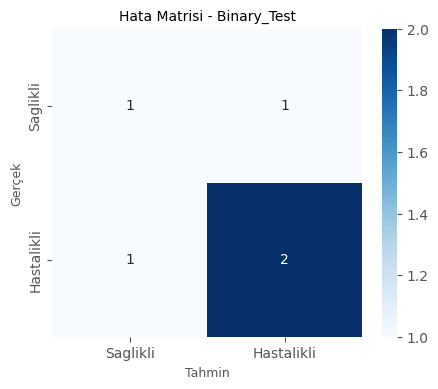

In [38]:
# Binary (İkili) Sınıflandırma Testi
binary_class_names = ['Saglikli', 'Hastalikli']
binary_true = [0, 1, 0, 1, 1]
binary_pred = [0, 1, 1, 1, 0]

# Fonksiyonu çağır (Daha önce düzelttiğimiz halini kullanacak)
plot_confusion_matrix(binary_true, binary_pred, binary_class_names, split_name="Binary_Test")